# Customer Purchasing Behavior Analysis



## Project Objective

The objective of this project is to analyze customer purchasing behavior using Python, SQL, Excel, and Power BI. The project focuses on understanding customer purchasing patterns, shopping trends, and business performance through data cleaning, exploratory data analysis (EDA), SQL analysis, interactive dashboards, and data visualization.

The insights generated from this project can help businesses improve customer satisfaction, optimize marketing strategies, and support data-driven decision-making.

# Table of Contents

1. Import Libraries
2. Load Dataset
3. Data Understanding
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Engineering
7. Business Insights
8. Recommendations
9. Conclusion

## 1. Import Libraries

In [59]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [60]:
# Load the dataset
df = pd.read_csv("../data/customer_shopping_behavior.csv")

In [61]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


## 3. Data Understanding

In [62]:
#Dataset Shape
df.shape

(3900, 18)

In [63]:
#Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [64]:
 #Statistical Summary
 df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [65]:
#Column Names
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='str')

In [66]:
#Data Types
df.dtypes

Customer ID                 int64
Age                         int64
Gender                        str
Item Purchased                str
Category                      str
Purchase Amount (USD)       int64
Location                      str
Size                          str
Color                         str
Season                        str
Review Rating             float64
Subscription Status           str
Shipping Type                 str
Discount Applied              str
Promo Code Used               str
Previous Purchases          int64
Payment Method                str
Frequency of Purchases        str
dtype: object

## 4. Data Cleaning


In [67]:
#checking missing values
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [68]:
 # checking duplicate values
 df.duplicated().sum()

np.int64(0)

In [69]:
#Filling missing values according to Review Rating
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [70]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [71]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={  'purchase_amount_(usd)':'purchase_amount'})

In [72]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [73]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18,25,35,45,55,65,80],
    labels=[
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65',
        '65+'
    ]
)

In [74]:
df[['age','age_group']].head()

,age,age_group
0,55,46-55
1,19,18-25
2,50,46-55
3,21,18-25
4,45,36-45


In [75]:
# create a column age_group
labels = ['Young Adult','Adult','Middel aged','Senior']
df['age_group'] = pd.qcut(df['age'],q=4,labels=labels)

In [76]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middel aged
1,19,Young Adult
2,50,Middel aged
3,21,Young Adult
4,45,Middel aged
5,46,Middel aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middel aged


In [77]:
# create column purchase_frequency_days
frequency_mapping = {
    'Weekly':7,
    'Bi-Weekly':14,
    'Monthly':30,
    'Quarterly':90,
    'Annually':365
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [78]:
df[['purchase_frequency_days','frequency_of_purchases']].head(7)

,purchase_frequency_days,frequency_of_purchases
0,NaN,Fortnightly
1,NaN,Fortnightly
2,7.0,Weekly
3,7.0,Weekly
4,365.0,Annually
5,7.0,Weekly
6,90.0,Quarterly


In [79]:
df['purchase_category'] = pd.cut(
    df['purchase_amount'],
    bins=[0,50,100,200,500],
    labels=[
        'Low',
        'Medium',
        'High',
        'Premium'
    ]
)

In [80]:
df[['purchase_amount','purchase_category']].head()

,purchase_amount,purchase_category
0,53,Medium
1,64,Medium
2,73,Medium
3,90,Medium
4,49,Low


In [81]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days,purchase_category
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Middel aged,NaN,Medium
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young Adult,NaN,Medium
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middel aged,7.0,Medium
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young Adult,7.0,Medium
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middel aged,365.0,Low


# 5. Exploratory Data Analysis (EDA)

###  Gender Distribution

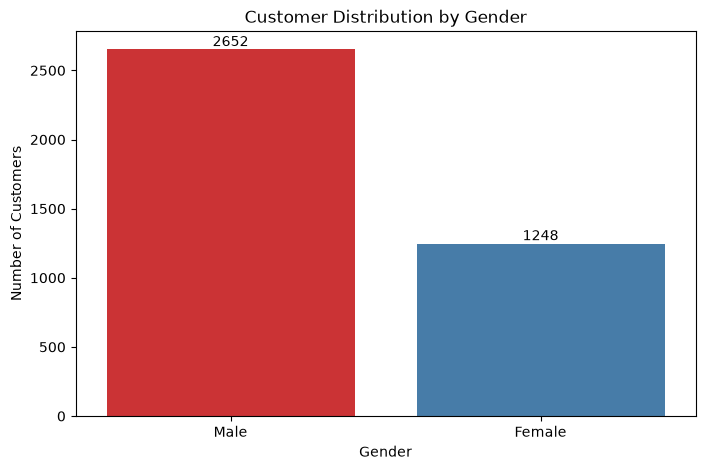

In [82]:
plt.figure(figsize=(8,5))

p=sns.countplot(data=df,x='gender',hue='gender',palette='Set1',legend=False)

# Show exact count on bars
for container in p.containers:
    p.bar_label(container)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

#### Observation

- The dataset contains **2,652 male customers** and **1,248 female customers**.
- Male customers represent the majority of the customer base.
- This indicates that the dataset is not evenly distributed across genders.

#### Business Insight

- Since male customers make up a larger portion of the customer base, businesses may focus marketing campaigns and product recommendations for this segment.
- At the same time, targeted promotions for female customers could help improve customer engagement and sales.

### Age Distribution

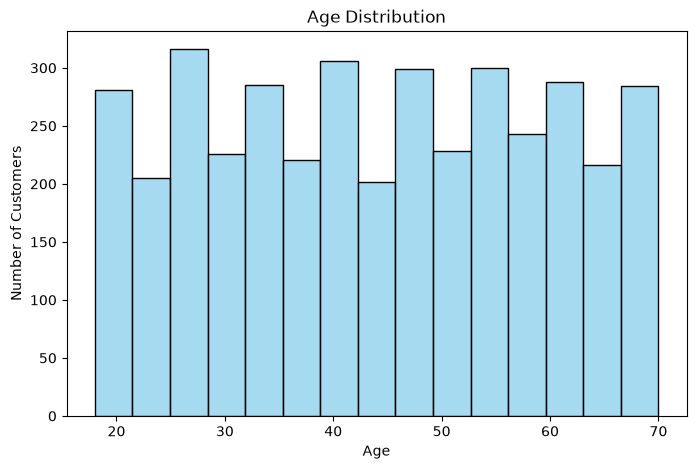

In [83]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='age',
    bins=15,
    color='skyblue'
)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

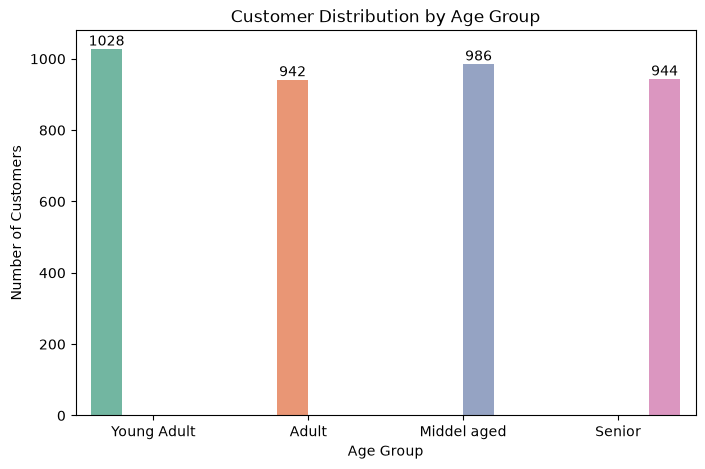

In [84]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='age_group',
    hue='age_group',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.show()

### Observation

- The **Young Adult** age group has the highest number of customers (1028).
- The **Middle Aged** group is the second largest customer segment (986).
- The **Senior** (944) and **Adult** (942) age groups have nearly the same number of customers.
- Overall, the customer distribution is fairly balanced across all age groups.

### Business Insight

- Since **Young Adults** represent the largest customer segment, businesses should prioritize products, promotions, and marketing campaigns tailored to this group.
- The **Middle Aged** segment also contributes significantly and can be targeted with personalized recommendations and loyalty programs.
- As the **Adult** and **Senior** groups have similar customer counts, businesses should continue offering products and services that cater to both segments to maintain engagement.

### Product Category Distribution

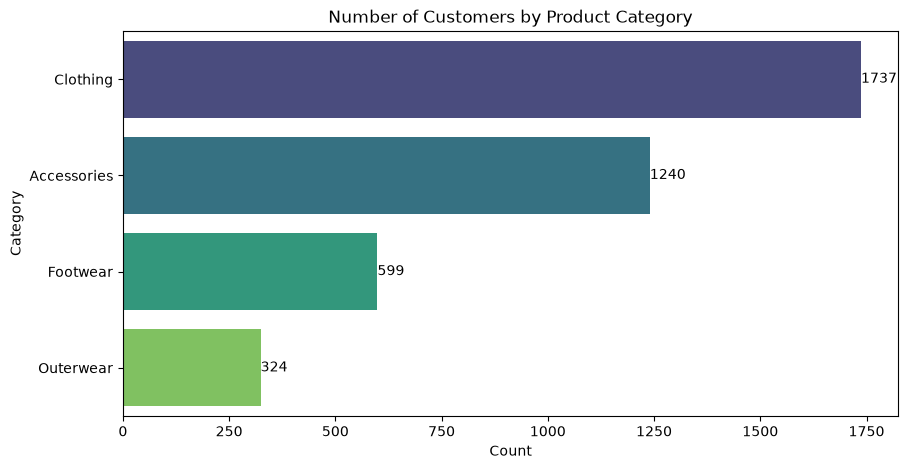

In [85]:

plt.figure(figsize=(10,5))

p=sns.countplot(
    data=df,
    y='category',
    order=df['category'].value_counts().index,
    palette='viridis'
)
for container in p.containers:
    p.bar_label(container)

plt.title('Number of Customers by Product Category')
plt.xlabel('Count')
plt.ylabel('Category')

plt.show()

### Observation

- The **Clothing** category has the highest number of customers (**1,737**), making it the most popular product category.
- **Accessories** is the second most purchased category with **1,240** customers.
- **Footwear** has a moderate customer count (**599**).
- **Outerwear** has the lowest customer count (**324**), indicating lower customer demand compared to other categories.

### Business Insight
- Customers purchasing Clothing may also be interested in complementary products such as Accessories. Businesses can use cross-selling strategies by recommending matching accessories during checkout.
- Cross-selling Clothing with Accessories can increase the average order value and improve the overall shopping experience.
- The relatively lower customer count for Outerwear may indicate seasonal purchasing behavior. Businesses should align inventory and marketing efforts with seasonal demand rather than maintaining uniform stock throughout the year.

### Purchase Amount Distribution

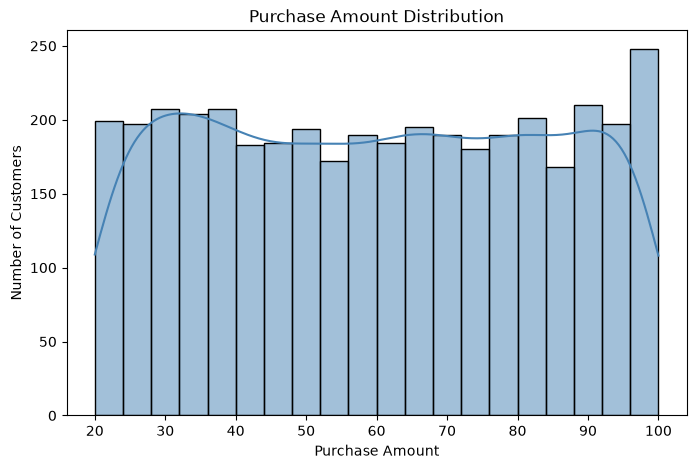

In [94]:
plt.figure(figsize=(8,5))

sns.histplot(data=df,x='purchase_amount',bins=20,kde=True,color='steelblue'
)

plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Number of Customers")

plt.show()

### Average Purchase Amount by Category

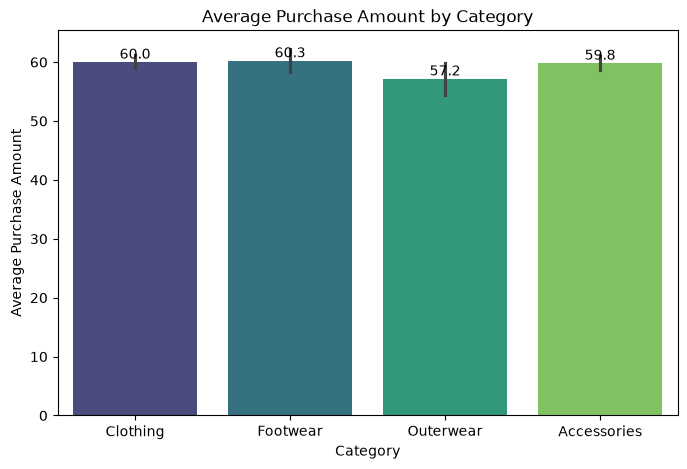

In [90]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=df,
    x='category',
    y='purchase_amount',
    estimator='mean',
    hue='category',
    palette='viridis',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title("Average Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Average Purchase Amount")

plt.show()

### Observation

- The average purchase amount is very similar across all product categories.
- Footwear has the highest average purchase amount (60.3).
- Clothing (60.0) and Accessories (59.8) have nearly identical average purchase amounts.
- Outerwear has the lowest average purchase amount (57.2).
- The difference in average spending between categories is relatively small.

### Business Insight

- Since the average purchase amount is consistent across categories, customer purchasing behavior appears stable. Business growth may depend more on attracting additional customers and increasing purchase frequency than on changing product prices.

#### Average Purchase Amount by Gender

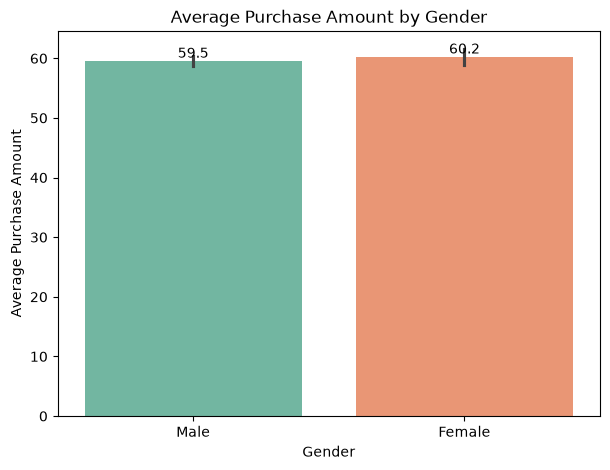

In [95]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=df,
    x='gender',
    y='purchase_amount',
    estimator='mean',
    hue='gender',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title("Average Purchase Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Purchase Amount")

plt.show()

### Observation

- Female customers have a slightly higher average purchase amount (60.2) than male customers (59.5).
- The difference in average spending between male and female customers is minimal (0.7).
- Overall, both genders exhibit very similar purchasing behavior.

### Business Insight

- Since female customers have a slightly higher average purchase amount, businesses can identify the factors driving this behavior and use them to enhance customer experience.
- As the spending difference between genders is very small, marketing strategies should focus on both male and female customers rather than targeting only one group.

#### Subscription Status

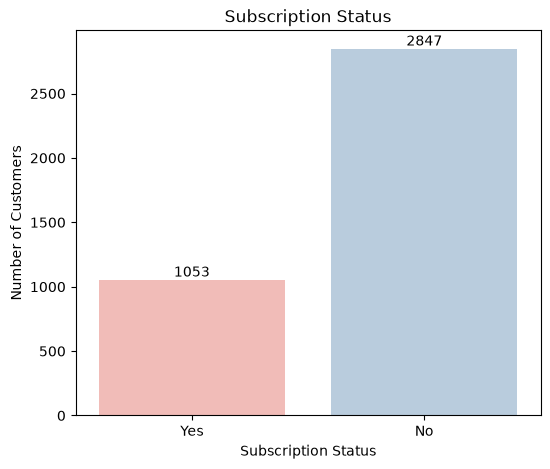

In [96]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x='subscription_status',
    hue='subscription_status',
    palette='Pastel1',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Number of Customers")

plt.show()

 ### Business Insight
- Most customers are not subscribed. The company should analyze the purchasing behavior of non-subscribers to understand what motivates them and identify opportunities to improve subscription adoption.

#### Average Purchase Amount by Subscription Status

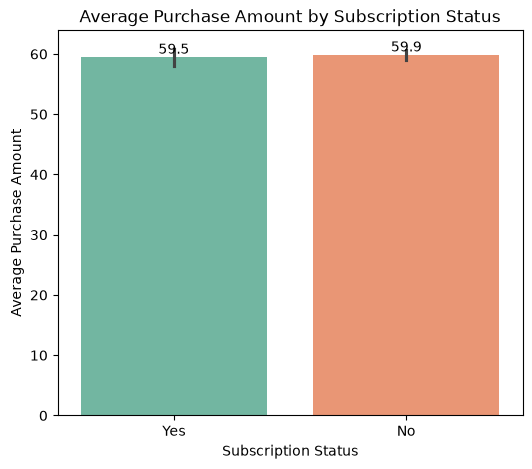

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=df,
    x='subscription_status',
    y='purchase_amount',
    estimator='mean',
    hue='subscription_status',
    palette='Set2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title("Average Purchase Amount by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Average Purchase Amount")

plt.show()

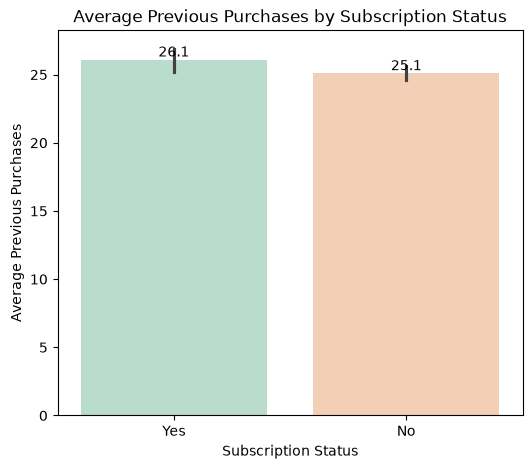

In [104]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=df,
    x='subscription_status',
    y='previous_purchases',
    estimator='mean',
    hue='subscription_status',
    palette='Pastel2',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title("Average Previous Purchases by Subscription Status")
plt.xlabel("Subscription Status")
plt.ylabel("Average Previous Purchases")

plt.show()

In [105]:
df.groupby('subscription_status')[['purchase_amount', 'previous_purchases']].mean().round(2)

,purchase_amount,previous_purchases
subscription_status,,
No,59.87,25.08
Yes,59.49,26.08


### Observation

- Non-subscribed customers have a slightly higher average purchase amount (59.87) than subscribed customers (59.49).
- Subscribed customers have a slightly higher average number of previous purchases (26.08) compared to non-subscribed customers (25.08).
- The differences are very small, indicating similar purchasing behavior between both groups.

#### Payment Method Distribution

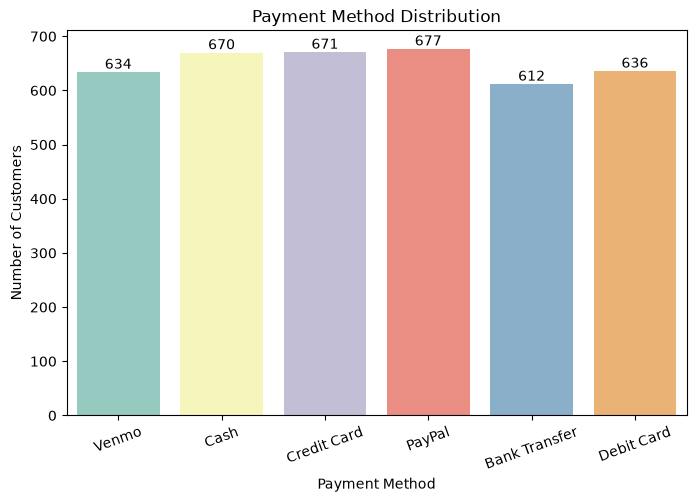

In [97]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='payment_method',
    hue='payment_method',
    palette='Set3',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

### Observation

- PayPal is the most frequently used payment method with **677 customers**.
- Credit Card (671) and Cash (670) are also widely used and have almost the same customer count.
- Bank Transfer is the least preferred payment method with **612 customers**.
- The customer count across all payment methods is fairly balanced, with only small differences between them.

### Business Insight

- Since customers use multiple payment methods at similar rates, the business should continue supporting a variety of payment options to provide flexibility and improve customer experience.
- PayPal, Credit Card, and Cash are the most preferred payment methods, so ensuring smooth and secure transactions for these options can enhance customer satisfaction.
- The lower usage of Bank Transfer suggests that customers may prefer faster and more convenient digital payment methods.

#### Purchases by Season

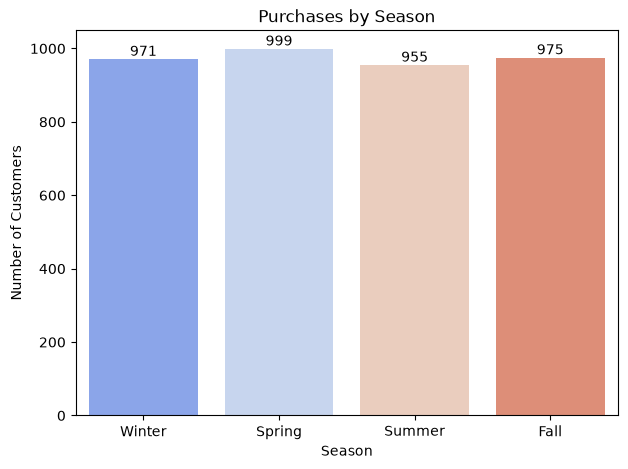

In [98]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x='season',
    hue='season',
    palette='coolwarm',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Purchases by Season")
plt.xlabel("Season")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- Spring has the highest number of customer purchases (999).
- Summer has the lowest number of customer purchases (955).
- Winter (971) and Fall (975) have very similar purchase counts.
- Overall, customer purchases are fairly evenly distributed across all four seasons.

### Business Insight

- Customer demand remains relatively stable throughout the year, indicating that the business does not rely heavily on a single season.
- Although Spring records the highest number of purchases, the difference across seasons is small, suggesting consistent customer buying behavior.
- Businesses should maintain inventory and marketing efforts throughout the year rather than focusing only on one season.

#### Correlation Heatmap

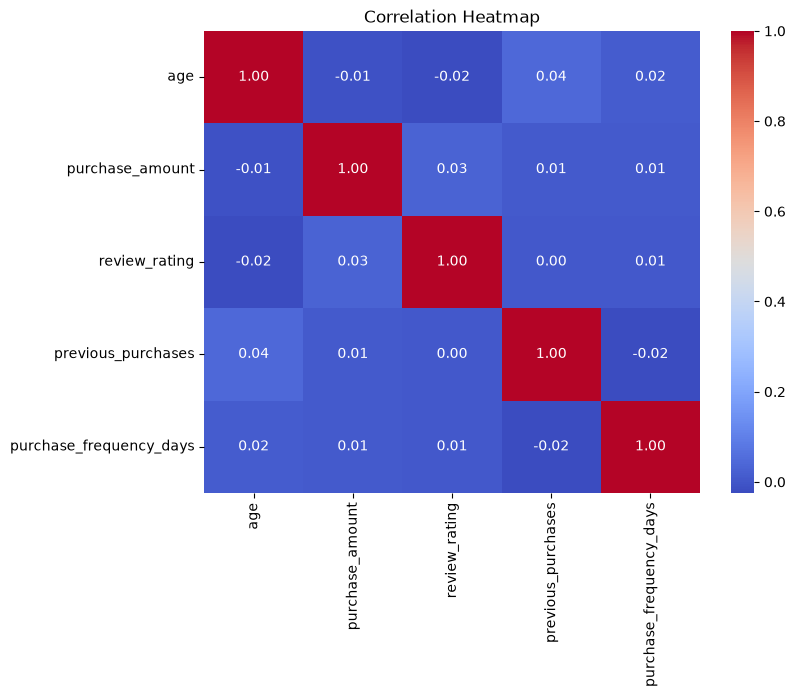

In [106]:
numeric_cols = [
    'age',
    'purchase_amount',
    'review_rating',
    'previous_purchases',
    'purchase_frequency_days'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()